In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version:{sqlite3.version}")


pandas version:2.2.2
sqlite3 version:2.6.0


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/student_performance.csv')

In [ ]:
df.head(3)

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
print(df.shape)

(30, 13)


In [ ]:
print(df.columns.tolist())

['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


In [ ]:
print(f"students:{df.shape[0]},{df.shape[1]}columns")

students:30,13columns


# Create SQLite Databse

sqlite3.connect() creates or opens a db file
conn is the connection ob
cursor is a tool like pen writes SQL commands into db

In [ ]:
conn=sqlite3.connect('college.db')

cursor=conn.cursor()

#students-->table

df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)

cursor.execute("SELECT count(*) FROM students")
count = cursor.fetchone()[0]

print(f"Database 'college.db' created successfully!" )
print(f"table 'students' has {count} rows")

Database 'college.db' created successfully!
table 'students' has 30 rows


In [ ]:
cursor.execute("PRAGMA  table_info(students)")
columns_info=cursor.fetchall()
print("Table structure of 'students':")
print(f"{'Column name':25} {'Data Type':<12}")
print("_" * 35)
for column in columns_info:
    print(f"{column[1]:25} {column[2]}")

Table structure of 'students':
Column name               Data Type   
___________________________________
student_id                INTEGER
name                      TEXT
age                       INTEGER
gender                    TEXT
department                TEXT
semester                  INTEGER
math_score                INTEGER
science_score             INTEGER
english_score             INTEGER
programming_score         INTEGER
attendance_percentage     INTEGER
city                      TEXT
admission_year            INTEGER


In [ ]:
def run_query(sql, description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f"{'='*55}")
  result=pd.read_sql(sql, conn)
  print(result.to_string(index=False))
  return result


In [ ]:
query1="""
  SELECT student_id, name, department, math_score, attendance_percentage
  FROM students
  LIMIT 10
"""
result=pd.read_sql_query(query1,conn)
result

,student_id,name,department,math_score,attendance_percentage
0,1001,Aarav Sharma,Computer Science,85,92
1,1002,Priya Patel,Computer Science,76,87
2,1003,Rohit Verma,Electronics,65,78
3,1004,Sneha Reddy,Mechanical,70,95
4,1005,Arjun Nair,Computer Science,92,90
5,1006,Meera Joshi,Electronics,58,72
6,1007,Kiran Kumar,Civil,73,85
7,1008,Divya Singh,Computer Science,88,96
8,1009,Rahul Mishra,Mechanical,62,68
9,1010,Ananya Das,Computer Science,95,98


In [ ]:
result1=run_query(query1, "Top 10 students(SELECT + LIMIT)")


Top 10 students(SELECT + LIMIT)
 student_id         name       department  math_score  attendance_percentage
       1001 Aarav Sharma Computer Science          85                     92
       1002  Priya Patel Computer Science          76                     87
       1003  Rohit Verma      Electronics          65                     78
       1004  Sneha Reddy       Mechanical          70                     95
       1005   Arjun Nair Computer Science          92                     90
       1006  Meera Joshi      Electronics          58                     72
       1007  Kiran Kumar            Civil          73                     85
       1008  Divya Singh Computer Science          88                     96
       1009 Rahul Mishra       Mechanical          62                     68
       1010   Ananya Das Computer Science          95                     98


In [ ]:
query2="""
  SELECT student_id, name, department, math_score, attendance_percentage
  FROM students
  LIMIT 5 OFFSET 25
"""
result2=run_query(query2, "Top 10 students(SELECT + LIMIT + OFFSET)")



Top 10 students(SELECT + LIMIT + OFFSET)
 student_id           name       department  math_score  attendance_percentage
       1026     Rekha Nair      Electronics          72                     82
       1027  Gaurav Shukla Computer Science          84                     87
       1028  Sunita Pillai            Civil          60                     73
       1029     Nitin Jain       Mechanical          75                     84
       1030 Akanksha Yadav Computer Science          91                     95


In [ ]:
query3="""
  SELECT student_id, name, department, programming_score
  FROM students
  WHERE programming_score BETWEEN 50 AND 70
  ORDER BY programming_score ASC
"""
result3=run_query(query3, "Students by Programming Score (ORDER BY DESC)")


Students by Programming Score (ORDER BY DESC)
 student_id          name  department  programming_score
       1029    Nitin Jain  Mechanical                 50
       1014 Kavya Nambiar  Mechanical                 51
       1006   Meera Joshi Electronics                 52
       1024 Preeti Saxena  Mechanical                 53
       1003   Rohit Verma Electronics                 55
       1021 Harish Pillai Electronics                 58
       1026    Rekha Nair Electronics                 63
       1016  Ritu Agarwal Electronics                 69


In [ ]:
query4="""
  SELECT student_id, name, department, programming_score
  FROM students
  WHERE department='Computer Science'
  ORDER BY programming_score ASC
"""

result4=run_query(query4, "Students by Programming Score in Computer Science department(ORDER BY ASSC)")


Students by Programming Score in Computer Science department(ORDER BY ASSC)
 student_id           name       department  programming_score
       1015    Ajay Tiwari Computer Science                 76
       1002    Priya Patel Computer Science                 79
       1020   Nisha Kapoor Computer Science                 83
       1027  Gaurav Shukla Computer Science                 87
       1013     Suresh Rao Computer Science                 88
       1025      Amit Bose Computer Science                 89
       1001   Aarav Sharma Computer Science                 91
       1018 Swati Kulkarni Computer Science                 92
       1008    Divya Singh Computer Science                 93
       1030 Akanksha Yadav Computer Science                 94
       1005     Arjun Nair Computer Science                 95
       1022    Tanvi Mehta Computer Science                 96
       1010     Ananya Das Computer Science                 97


In [ ]:
queryy="""
  SELECT DISTINCT department
  FROM students
"""
result5=run_query(queryy, "Top 3 departments")


Top 3 departments
      department
Computer Science
     Electronics
      Mechanical
           Civil


In [ ]:
query5="""
  SELECT DISTINCT department
  FROM students
  LIMIT 3
"""
result5=run_query(query5, "Top 3 departments")
print("="*30)

query6="""
  SELECT department,name, programming_score FROM students
  ORDER BY programming_score DESC
  LIMIT 3
"""
result6=run_query(query6, "Student with highest programming score")


Top 3 departments
      department
Computer Science
     Electronics
      Mechanical

Student with highest programming score
      department        name  programming_score
Computer Science  Ananya Das                 97
Computer Science Tanvi Mehta                 96
Computer Science  Arjun Nair                 95


In [ ]:
query7="""
  SELECT student_id, name, department, attendance_percentage
  FROM students
  WHERE attendance_percentage > 90
  AND department!='Civil'
  ORDER BY attendance_percentage ASC
"""
result7=run_query(query7, "Students with low attendance percentage")


Students with low attendance percentage
 student_id           name       department  attendance_percentage
       1009   Rahul Mishra       Mechanical                     68
       1006    Meera Joshi      Electronics                     72
       1021  Harish Pillai      Electronics                     74
       1015    Ajay Tiwari Computer Science                     75
       1019 Deepak Chauhan       Mechanical                     77
       1003    Rohit Verma      Electronics                     78
       1026     Rekha Nair      Electronics                     82
       1011    Vikram Iyer      Electronics                     83
       1029     Nitin Jain       Mechanical                     84
       1024  Preeti Saxena       Mechanical                     86
       1002    Priya Patel Computer Science                     87
       1027  Gaurav Shukla Computer Science                     87
       1013     Suresh Rao Computer Science                     88
       1020   Nisha K

In [ ]:
query7="""
  SELECT student_id, name, department, attendance_percentage
  FROM students
  WHERE attendance_percentage != 80
  ORDER BY attendance_percentage ASC
"""

result7=run_query(query7, "Students not equal to 80% attendance")


Students not equal to 80% attendance
 student_id           name       department  attendance_percentage
       1017   Manoj Pandey            Civil                     65
       1009   Rahul Mishra       Mechanical                     68
       1023   Sanjay Dubey            Civil                     70
       1006    Meera Joshi      Electronics                     72
       1028  Sunita Pillai            Civil                     73
       1021  Harish Pillai      Electronics                     74
       1015    Ajay Tiwari Computer Science                     75
       1019 Deepak Chauhan       Mechanical                     77
       1003    Rohit Verma      Electronics                     78
       1026     Rekha Nair      Electronics                     82
       1011    Vikram Iyer      Electronics                     83
       1029     Nitin Jain       Mechanical                     84
       1007    Kiran Kumar            Civil                     85
       1024  Preeti Saxe

In [ ]:
query_join="""
select s.name,
s.math_score,
d.dept_name,
d.intake,
d.established
from students AS s
inner join departments as d
on s.dept_code=d.dept_code
order by s.math_score DESC
limit 8
"""
result1=run_query(query_join,"query 13:(select+innerjoin+orderby)")


query 13:(select+innerjoin+orderby)
          name  math_score        dept_name  intake  established
    Ananya Das          95 Computer Science      60         1985
   Tanvi Mehta          93 Computer Science      60         1985
    Arjun Nair          92 Computer Science      60         1985
Akanksha Yadav          91 Computer Science      60         1985
Swati Kulkarni          90 Computer Science      60         1985
   Divya Singh          88 Computer Science      60         1985
  Ritu Agarwal          87      Electronics      60         1988
     Amit Bose          86 Computer Science      60         1985


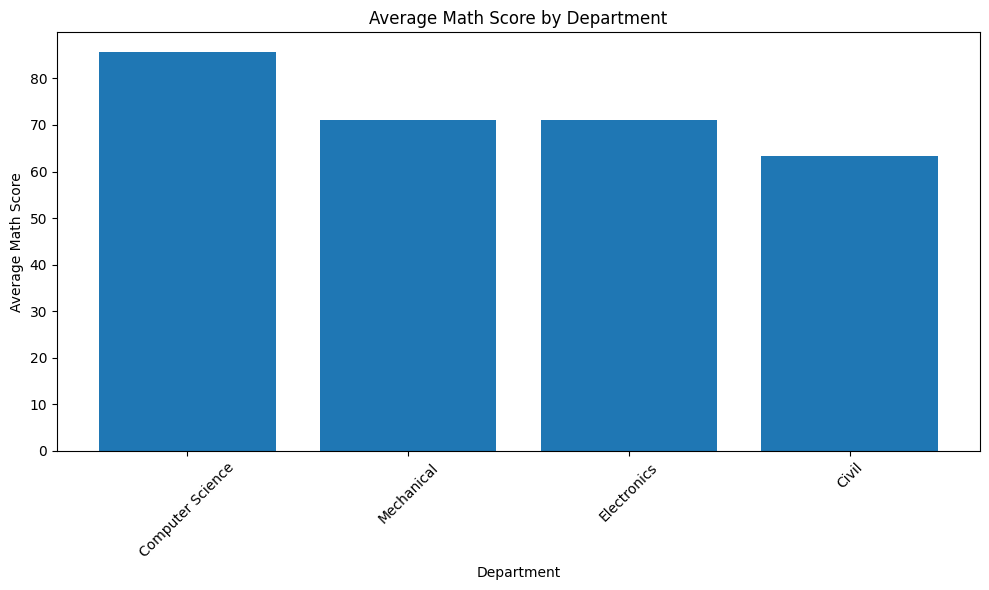

In [ ]:
chart1_sql="""
SELECT department,ROUND(AVG(math_score),2) AS avg_math
FROM students
GROUP BY department
ORDER BY avg_math DESC
"""
chart1_data=pd.read_sql_query(chart1_sql,conn)

fig, ax=plt.subplots(figsize=(10,6))
ax.bar(chart1_data['department'],chart1_data['avg_math'])
ax.set_xlabel('Department')
ax.set_ylabel('Average Math Score')
ax.set_title('Average Math Score by Department')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()